# Instructor solution: Challenge 1

Run from this folder using a Python environment with numpy, pandas, matplotlib, scikit-learn and Jupyter. Student-facing answers must remain outside public/. The recorded choice prioritizes simplicity; other evidence-based choices are defensible.

## Checkpoint 1: Look at the data · 0–8 minutes
Load the synthetic dataset: `x` is one unitless input and `y` is a continuous unitless response; these are not measurements of a real population. Inspect variables and missing values, then make a scatterplot. This initial overview is exploratory; after the split, all comparisons must use training data only.

Before fitting anything: **Would you expect one straight line to describe this relationship well? What would you look for after fitting the model to decide whether the straight line is missing something?**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# One place to update the release location, if necessary.
DATA_URL = "https://raw.githubusercontent.com/UPEI-CS/CS-4120-Students/main/challenges/challenge-01/data/challenge-01-data.csv"
LOCAL_CSV = Path("../../../public/challenges/challenge-01/data/challenge-01-data.csv")
# Local clone: use data/. Before publication in Colab: upload the provided CSV.
UPLOADED_CSV = Path("challenge-01-data.csv")
if LOCAL_CSV.exists():
    data = pd.read_csv(LOCAL_CSV)
elif UPLOADED_CSV.exists():
    data = pd.read_csv(UPLOADED_CSV)
else:
    data = pd.read_csv(DATA_URL)
assert list(data.columns) == ["x", "y"] and not data.isna().any().any()

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def residual_plot(X, actual, predicted, title):
    plt.figure(figsize=(6, 3))
    plt.scatter(X["x"], actual - predicted, alpha=0.7)
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("x"); plt.ylabel("Observed minus predicted y")
    plt.title(title); plt.show()

def relationship_plot(model, X, actual, title):
    grid = pd.DataFrame({"x": np.linspace(X["x"].min(), X["x"].max(), 200)})
    plt.figure(figsize=(6, 3))
    plt.scatter(X["x"], actual, alpha=0.6)
    plt.plot(grid["x"], model.predict(grid), color="darkorange")
    plt.xlabel("x"); plt.ylabel("y"); plt.title(title); plt.show()

,x,y
0,1.186417,4.700846
1,-1.117114,-4.341801
2,-2.272817,6.906997
3,-1.058451,0.191284
4,2.587271,19.396969


,x,y
count,120.000000,120.000000
mean,0.108003,7.983348
std,1.780882,6.088110
min,-2.967108,-4.341801
25%,-1.368638,3.979575
50%,0.256522,6.682042
75%,1.636181,12.374427
max,2.987006,26.590225


x    0
y    0
dtype: int64


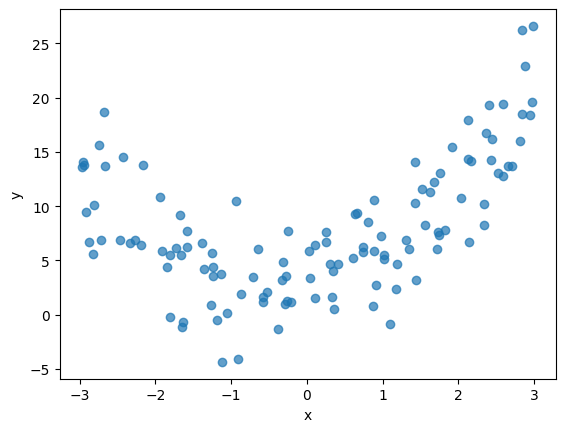

In [2]:
display(data.head())
display(data.describe())
print(data.isna().sum())
plt.scatter(data["x"], data["y"], alpha=0.7)
plt.xlabel("x"); plt.ylabel("y"); plt.show()

**Reference observation:** The scatterplot has a curved bowl shape with substantial noise. One straight line will miss structure; I would look for a curved residual pattern rather than unstructured scatter around zero.

## Checkpoint 2: Establish a baseline · 8–18 minutes
Run the reproducible 80/20 split. The test set is now reserved until Checkpoint 7. Fit ordinary linear regression on all training data. The metrics below describe training fit; they are not an estimate of performance on new cases.

**What pattern do you see in the residuals? If the model were capturing the relationship well, what would you expect the residuals to look like?** RMSE is in target units (lower is better); R² can be negative (higher is better).

,partition,RMSE,R2
0,training (not generalization),5.35062,0.243478


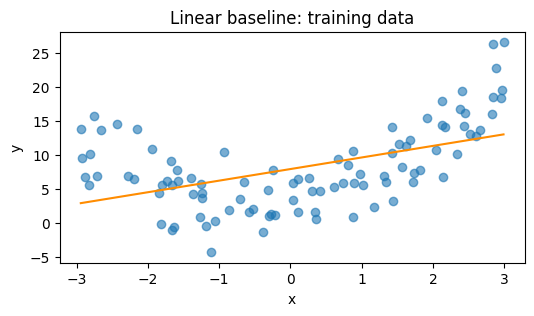

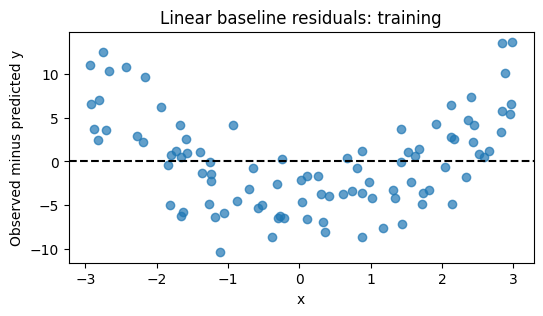

In [3]:
X = data[["x"]]  # two-dimensional input, as required by scikit-learn
y = data["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
# Only training data are used below. Test variables stay closed until Checkpoint 7.
baseline = LinearRegression().fit(X_train, y_train)
baseline_predictions = baseline.predict(X_train)
display(pd.DataFrame([{"partition": "training (not generalization)",
                       "RMSE": rmse(y_train, baseline_predictions),
                       "R2": r2_score(y_train, baseline_predictions)}]))
relationship_plot(baseline, X_train, y_train, "Linear baseline: training data")
residual_plot(X_train, y_train, baseline_predictions, "Linear baseline residuals: training")

**Reference residual evidence:** The residuals are generally positive toward the ends and negative near the middle. The missing curvature makes a richer input representation plausible.

### AI partner interaction 1
Observe first, then ask:

> My linear regression residuals show a curved pattern. I still want to use linear regression as the estimator. Is there a way to change how the input features are represented so the model can capture curvature? Do not give me a complete solution. Help me understand the idea and decide what I should try next.

**Record:** What did the AI partner suggest? Why does it make sense based on your residual plot? Check the idea in the next checkpoint.

## Checkpoint 3: Experiment with complexity · 18–30 minutes
Polynomial features represent `x` using powers such as `x`, `x²`, and so on. The estimator is still linear in its coefficients. After your conversation, use the support code below and activate degrees 1 through 6. It handles repetitive mechanics so you can compare evidence.

Split only the training partition into fitting/validation portions. Record training and validation RMSE for every degree. **What happens to training error as degree increases? Does the most complex model automatically give the best validation result? Which degree would you choose using only this split, and why?**

In [4]:
from sklearn.preprocessing import PolynomialFeatures

# Run this support cell AFTER your first AI partner conversation.
# The estimator is still LinearRegression; only its input representation changes.
class PolynomialModel:
    def __init__(self, degree):
        self.features = PolynomialFeatures(degree=degree, include_bias=False)
        self.estimator = LinearRegression()
    def fit(self, X, y):
        transformed = self.features.fit_transform(X)
        self.estimator.fit(transformed, y)
        return self
    def predict(self, X):
        return self.estimator.predict(self.features.transform(X))

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=17
)
degrees = list(range(1, 7))
rows = []
for degree in degrees:
    model = PolynomialModel(degree).fit(X_fit, y_fit)
    rows.append({"degree": degree, "training_RMSE": rmse(y_fit, model.predict(X_fit)),
                 "validation_RMSE": rmse(y_valid, model.predict(X_valid))})
split_results = pd.DataFrame(rows)
display(split_results)
if not degrees:
    print("Choose the requested degree range above to start your comparison.")

,degree,training_RMSE,validation_RMSE
0,1,5.336280,5.510594
1,2,3.481922,3.340136
2,3,3.479943,3.332569
3,4,3.477826,3.336724
4,5,3.366657,3.432424
5,6,3.366195,3.413878


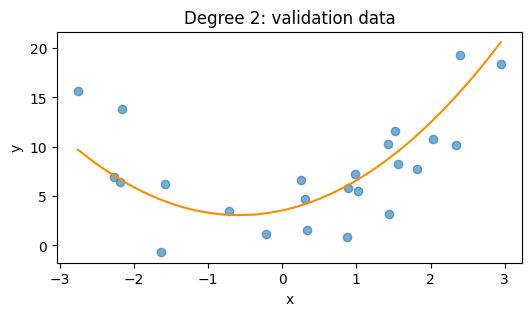

In [5]:
plot_degree = 2  # Compare with a simpler or more complex model if useful.
if plot_degree in degrees:
    model = PolynomialModel(plot_degree).fit(X_fit, y_fit)
    relationship_plot(model, X_valid, y_valid, f"Degree {plot_degree}: validation data")

**Reference single-split interpretation:** Training RMSE falls from 5.3363 to 3.3662 as degree rises from 1 to 6. Validation RMSE is lowest for degree 3 (3.3326), but degrees 2 (3.3401) and 4 (3.3367) are extremely close. My provisional degree-3 choice should be checked across other held-out groups.

### AI partner interaction 2
Predict whether another split might change your ranking, then ask:

> I chose a polynomial degree using one training/validation split. If I changed the random split, could my conclusion change? What experiment could I use to make this model comparison more reliable? Explain the reasoning before giving me code.

**Assess and explain:** What experiment was suggested, and why is it more reliable? If time permits, rerun the split with another seed; keep the test set closed.

## Checkpoint 4: Test the decision, not the test set · 30–43 minutes
Use five shuffled folds, fixed seed 42, on the training data. Each case is validated once; every fold fits a fresh model. The supplied loop repeats the mechanics; follow where the fitting and validation rows go.

Compare degrees 1 through 6 using mean RMSE, standard deviation and individual fold values. **Is your single-split choice still your choice? Are some models more variable across folds? Why care about both average performance and variability?**

The fold standard deviation describes spread; it is not a confidence interval or proof that one model is significantly better. Compare all degrees on the same folds.

In [6]:
folds = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rows = []
for degree in degrees:
    for fold, (fit_ids, valid_ids) in enumerate(folds.split(X_train), start=1):
        # A fresh feature transformer and estimator for every fold.
        model = PolynomialModel(degree).fit(X_train.iloc[fit_ids], y_train.iloc[fit_ids])
        predictions = model.predict(X_train.iloc[valid_ids])
        fold_rows.append({"degree": degree, "fold": fold,
                          "RMSE": rmse(y_train.iloc[valid_ids], predictions)})
fold_results = pd.DataFrame(fold_rows)
if len(fold_results):
    cv_results = fold_results.groupby("degree")["RMSE"].agg(["mean", "std"])
    display(cv_results)  # sample standard deviation across the 5 fold RMSEs
    display(fold_results.pivot(index="degree", columns="fold", values="RMSE"))
else:
    print("First activate the degree range in Checkpoint 3.")

,mean,std
degree,,
1,5.543024,0.547073
2,3.535011,0.276253
3,3.573755,0.299483
4,3.651713,0.343470
5,3.591735,0.500936
6,3.604305,0.489599


fold,1,2,3,4,5
degree,,,,,
1,5.793151,4.949007,5.624815,6.282638,5.065511
2,3.361721,3.533904,3.647963,3.926694,3.204771
3,3.361371,3.690022,3.647357,3.968720,3.201303
4,3.469974,3.692234,3.785191,4.113497,3.197671
5,3.284317,3.584135,3.760273,4.324540,3.005412
6,3.254842,3.623368,3.764675,4.320259,3.058382


**Reference CV interpretation:** Degree 2 has mean RMSE 3.5350 and fold SD 0.2763; degree 3 has 3.5738 and 0.2995. Degrees 5 and 6 have SD near 0.50 without better means. I now favor degree 2. The ranking reversal from one split matters more than its tiny decimal gap. Fold spread describes sensitivity to the held-out group, not statistical significance.

## Checkpoint 5: Keeping the modelling steps together · 43–55 minutes
We now generate features before fitting an estimator. Consider adding scaling so polynomial feature columns use comparable scales. Predict which rows each transformation may learn from, then ask:

> My model now requires transformations before linear regression, and I am evaluating it using cross-validation. When cross-validation creates each training fold and validation fold, when should those transformations be learned? Is there a scikit-learn tool that can keep the transformations and model together as one modelling workflow? Explain why this matters before showing me how to use it.

**Before continuing:** Explain what would go wrong if a transformation learned information from a validation fold. Which part of your current transformation is learned from observed values?

### After the conversation: try the tool
`sklearn.pipeline.Pipeline` keeps transformations and the estimator together. Complete the function below with help from your AI partner, then evaluate it using the supplied loop. Explain why fitting occurs inside each fold.

`PolynomialFeatures` generates a fixed set of powers for a chosen degree; unlike a scaler, it does not estimate means or variances. `StandardScaler` **does** learn these from data and must fit only on each fitting fold. Scaling is not essential to unregularized least squares here and should not materially change predictions; it demonstrates a learned transformation and can improve numerical conditioning. Always transform validation/test rows using the training-fitted steps.

Check that the two CV tables agree to numerical precision. The workflow provides consistent fitting and prediction, not a promise of lower error.

In [7]:
# After your third AI partner conversation, complete this one function.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def build_workflow(degree):
    # Return a Pipeline with named steps for PolynomialFeatures
    # (include_bias=False), StandardScaler, and LinearRegression, in that order.
    # Ask your AI partner for a small syntax example if needed, then explain it.
    return Pipeline([( "powers", PolynomialFeatures(degree=degree, include_bias=False)),
                     ("scale", StandardScaler()), ("regression", LinearRegression())])

workflow_rows = []
for degree in degrees:
    workflow = build_workflow(degree)
    if workflow is None:
        print("Complete build_workflow before comparing complete workflows.")
        break
    scores = -cross_val_score(workflow, X_train, y_train, cv=folds,
                             scoring="neg_root_mean_squared_error")
    workflow_rows.append({"degree": degree, "mean_CV_RMSE": scores.mean(),
                          "sd_CV_RMSE": scores.std(ddof=1)})
workflow_results = pd.DataFrame(workflow_rows)
display(workflow_results)

,degree,mean_CV_RMSE,sd_CV_RMSE
0,1,5.543024,0.547073
1,2,3.535011,0.276253
2,3,3.573755,0.299483
3,4,3.651713,0.343470
4,5,3.591735,0.500936
5,6,3.604305,0.489599


**Reference explanation:** For a fixed degree, polynomial powers are predetermined. Scaling learns feature means and standard deviations; regression learns coefficients. Each CV clone fits these learned steps only on its fitting fold. Validation data pass through transform/predict, never fit. The final workflow repeats this on all training data before predicting the test data.

## Checkpoint 6: Make the decision · 55–60 minutes
Choose a polynomial degree **before touching the test set**. Justify it using mean CV RMSE, variation across folds, complexity and your plots. A tiny improvement may not justify extra complexity; there is no requirement to choose the largest degree or blindly take a table's minimum.

**Reference decision (before testing):** Choose degree 2: it removes obvious curvature, has the lowest CV mean, low fold spread and fewer coefficients than the close alternatives. Expect RMSE roughly in the mid-3s, allowing variation for a 24-case test set. A much larger error or a renewed curved residual pattern would warrant investigation, not immediate test-driven retuning.

In [8]:
chosen_degree = 2  # Reference choice justified above.

## Checkpoint 7: Final evaluation · 60–68 minutes
Only now enable the cell below. Fit the chosen workflow on **all** training data, evaluate **once** on the held-out test set, and report RMSE, R² and residuals. Do not revise your degree based on this test result. The guard prevents accidental repeat evaluation in this session; restarting the runtime resets it, so the experimental rule remains your responsibility.

**Is final test performance reasonably consistent with cross-validation? What would concern you?** With only 24 test cases, expect some sampling variation.

,test_RMSE,test_R2
0,3.712293,0.56622


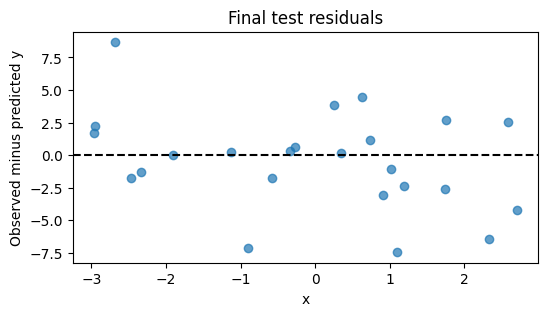

In [9]:
# Only set True after writing your model-choice justification in Checkpoint 6.
RUN_FINAL_EVALUATION = True
if RUN_FINAL_EVALUATION:
    if chosen_degree not in degrees or build_workflow(chosen_degree) is None:
        raise ValueError("Finish your workflow and choose one investigated degree first.")
    if globals().get("test_already_used", False):
        print("Test evaluation already run. Use the recorded result; do not tune against it.")
    else:
        final_model = build_workflow(chosen_degree).fit(X_train, y_train)
        test_predictions = final_model.predict(X_test)
        test_already_used = True
        display(pd.DataFrame([{"test_RMSE": rmse(y_test, test_predictions),
                               "test_R2": r2_score(y_test, test_predictions)}]))
        residual_plot(X_test, y_test, test_predictions, "Final test residuals")
else:
    print("Test set remains untouched. Enable this only after your decision is recorded.")

**Reference final evaluation:** Test RMSE 3.7123 and R² 0.5662 are reasonably consistent with CV RMSE 3.5350. The small test set is noisy; inspect the residual plot without demanding perfect randomness. Keep this result as the final audit of the choice.

## 8. Report back

**68-75 minutes**

Work together to answer the eight challenge questions in your group's Word document. Support your group answers with evidence from the completed notebook, including plots, RMSE values, cross-validation results, fold variability, and the final test evaluation.

1. Which polynomial degree did your group choose?
2. What evidence supports that choice?
3. Why was one training/validation split not enough to make the decision confidently?
4. What did the variation across the cross-validation folds tell you?
5. What problem does Pipeline help solve in this experiment?
6. What did your AI partner help clarify during the challenge?
7. After seeing the final test results, do you still think your model choice was reasonable? Explain using the evidence.
8. What is one thing your group would investigate next if you continued this experiment?

## Submission

Submit one ZIP file per group to Moodle. The ZIP file should contain:

- The group's completed Google Colab notebook (.ipynb), including code, plots, tables, cross-validation results, and final test evaluation.
- One Word document (.docx) containing the group's answers to the eight challenge questions.

At the top of the Word document include:

> Challenge 1: When a Straight Line Is Not Enough
> Group members:
> Student IDs:

Only one member of the group needs to submit the ZIP file.

Provide one set of group answers; separate answers from every group member are not required.

An AI partner transcript is not required. For the AI partner question, explain in your own words what the AI partner helped your group understand. Do not paste the conversation.

### Instructor reference for the group answers

1. Our group chose degree 2.
2. It captures the curved relationship, with mean CV RMSE 3.5350 and fold SD 0.2763, while using fewer coefficients than the close alternatives.
3. One split narrowly favors degree 3 (validation RMSE 3.3326 versus 3.3401 for degree 2); the ranking changes under CV.
4. Degrees 5 and 6 have larger fold spread (about 0.50) without improving the average, suggesting sensitivity to the held-out rows.
5. Pipeline fits learned transformations within each training fold and applies the same steps consistently at prediction time.
6. Groups should describe their actual AI partner contribution, such as clarifying why powers of x can capture curvature or why transformations are refitted inside CV; do not invent an interaction.
7. Yes: test RMSE 3.7123 and test R² 0.5662 are reasonably consistent with CV evidence. The test residual plot lacks the strong baseline curvature. This supports the choice without using the test set to retune.
8. We would investigate stability with repeated CV on training data or gather more data; we would not reuse this test set for tuning.


Students will work in different teams in future challenges. Their feedback and experience from this challenge should inform their work in the next team.


## Instructor interpretation
The linear residuals curve above and below zero systematically. Powers of x let a linear estimator represent curvature. The single split narrowly prefers degree 3, whereas five-fold CV favors degree 2. Degrees 2 and 3 are close: the simpler quadratic is a defensible teaching choice, not a universal law. Higher degrees reduce training error without useful CV gains; fold spread is larger for degrees 5 and 6. The test result is a final audit, not a further selection signal. PolynomialFeatures has fixed powers; StandardScaler and regression learn fold-specific parameters. Pipeline ensures the complete process is re-fitted inside each fold.

Do not claim that all extra degrees must increase fold variability monotonically, or that overlapping fold spreads establish statistical equivalence. If students choose degree 3 with sound evidence, accept the reasoning. Their next investigation might use repeated CV or more observations, retaining a fresh test set for any new selection cycle.

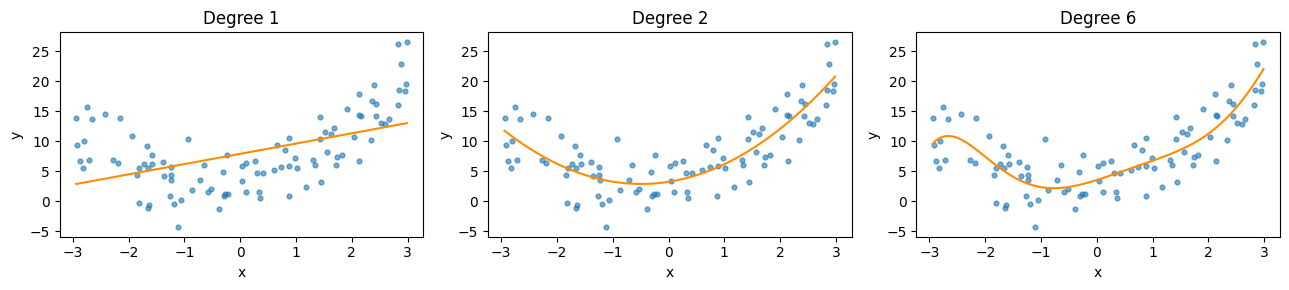

In [10]:
# Additional instructor-only check: compare curves on training data, never re-tune on test.
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
grid = pd.DataFrame({"x": np.linspace(X_train.x.min(), X_train.x.max(), 250)})
for ax, degree in zip(axes, [1, 2, 6]):
    model = build_workflow(degree).fit(X_train, y_train)
    ax.scatter(X_train.x, y_train, s=12, alpha=0.6)
    ax.plot(grid.x, model.predict(grid), color="darkorange")
    ax.set(title=f"Degree {degree}", xlabel="x", ylabel="y")
plt.tight_layout(); plt.show()


In [11]:
# Verify the complete workflow reproduces the manual fold comparison.
np.testing.assert_allclose(cv_results["mean"], workflow_results["mean_CV_RMSE"], rtol=1e-9)
np.testing.assert_allclose(cv_results["std"], workflow_results["sd_CV_RMSE"], rtol=1e-9)
assert int(split_results.loc[split_results.validation_RMSE.idxmin(), "degree"]) == 3
assert int(workflow_results.loc[workflow_results.mean_CV_RMSE.idxmin(), "degree"]) == 2
assert len(X_train) == 96 and len(X_test) == 24
assert test_already_used
